--- Class Balance (Training Set) ---
label
0    0.603116
1    0.396884
Name: proportion, dtype: float64

--- Class Balance (Validation Set) ---
label
0    0.602492
1    0.397508
Name: proportion, dtype: float64

--- Class Balance (Test Set) ---
label
0    0.603261
1    0.396739
Name: proportion, dtype: float64


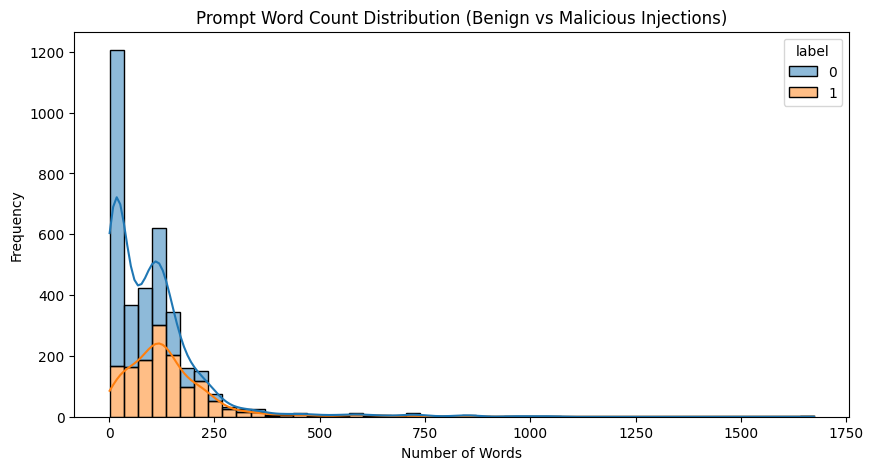

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create the results directory just in case it isn't there
os.makedirs("../results", exist_ok=True)

# 1. Load the frozen splits from the data folder
train_df = pd.read_csv("../data/frozen_train_set.csv")
val_df = pd.read_csv("../data/frozen_val_set.csv")
test_df = pd.read_csv("../data/frozen_test_set.csv")

# 2. Print class balance ratios to prove the data isn't skewed (eg: 95% benign, 5% malicious)
print("--- Class Balance (Training Set) ---")
print(train_df['label'].value_counts(normalize=True))

print("\n--- Class Balance (Validation Set) ---")
print(val_df['label'].value_counts(normalize=True))

print("\n--- Class Balance (Test Set) ---")
print(test_df['label'].value_counts(normalize=True))

# 3. Document Word lengths to map the attack taxonomy
train_df['word_count'] = train_df['text'].apply(lambda x: len(str(x).split()))

# 4. Plot Text Length Distributions by Class
plt.figure(figsize=(10, 5))
sns.histplot(data=train_df, x="word_count", hue="label", kde=True, multiple="stack", bins=50)
plt.title("Prompt Word Count Distribution (Benign vs Malicious Injections)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

# 5. Save the graph for final technical report
plt.savefig("../results/word_count_distribution.png")
plt.show()

Exploratory Data Analysis confirms a healthy class distribution of approximately 60.3% benign instances and 39.7% adversarial injections. Stratified sampling was successfully implemented during the 64/16/20 train-val-test split, ensuring the frozen test partition maintains an identical class ratio (60.3% / 39.7%) to prevent data leakage and guarantee representative baseline evaluations

--- Attack Sub-Type Breakdown ---
attack_subtype
Spoofing / Roleplay              639
Direct / Uncategorized           474
Tampering / Override             231
Information Disclosure / Leak     54
Obfuscation / Encoding             3
Name: count, dtype: int64


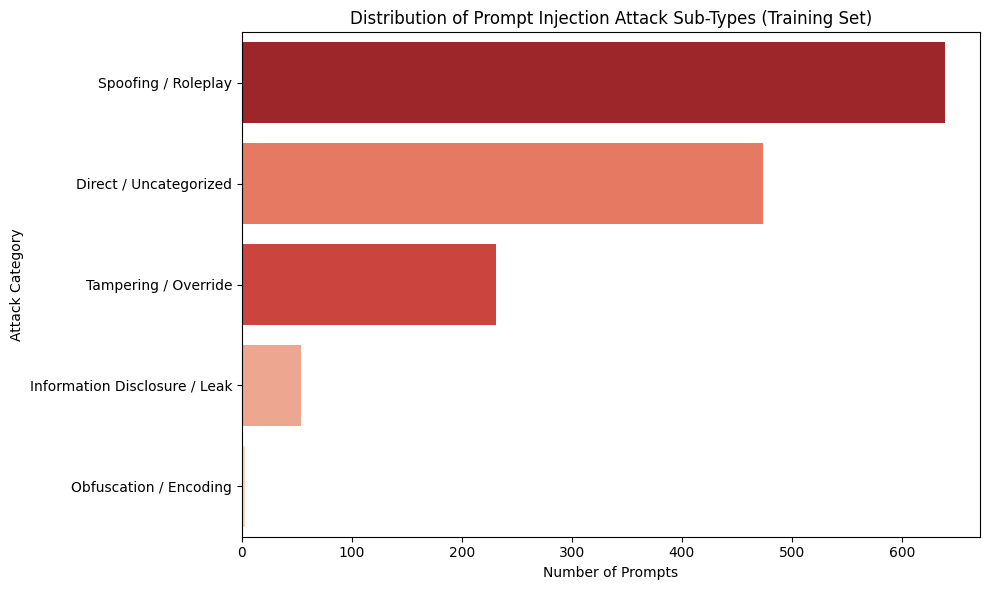

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Keyword-Based Heuristic Tagging (Rule-based NLP technique

# 1. Isolate only the malicious prompts from the training set
train_df = pd.read_csv("../data/frozen_train_set.csv")
malicious_df = train_df[train_df['label'] == 1].copy()

# 2. Define heuristic dictionary (Mapping keywords to Threat Model categories)
heuristics = {
    'Spoofing / Roleplay': ['act as', 'pretend', 'you are', 'dan', 'persona', 'developer mode'],
    'Tampering / Override': ['ignore', 'disregard', 'override', 'forget', 'instead'],
    'Information Disclosure / Leak': ['system prompt', 'instructions', 'leak', 'tell me your', 'output your'],
    'Obfuscation / Encoding': ['base64', 'hex', 'decode', 'translate'],
}

# 3. Create the tagging logic function
def tag_attack_type(text):
    text_lower = str(text).lower()
    for category, keywords in heuristics.items():
        # If any keyword from the list is in the prompt, assign that category
        if any(keyword in text_lower for keyword in keywords):
            return category
    
    # If no specific keywords are found, label it as a Direct/Uncategorized attack
    return 'Direct / Uncategorized'

# 4. Apply the function to create a new column
malicious_df['attack_subtype'] = malicious_df['text'].apply(tag_attack_type)

# 5. Print the breakdown for the console
print("--- Attack Sub-Type Breakdown ---")
print(malicious_df['attack_subtype'].value_counts())

# 6. Plot the distribution for the final report
plt.figure(figsize=(10, 6))
# Using a red color palette to signify malicious inputs
sns.countplot(
    data=malicious_df, 
    y='attack_subtype', 
    hue='attack_subtype', 
    legend=False,
    order=malicious_df['attack_subtype'].value_counts().index, 
    palette='Reds_r'
)
plt.title("Distribution of Prompt Injection Attack Sub-Types (Training Set)")
plt.xlabel("Number of Prompts")
plt.ylabel("Attack Category")
plt.tight_layout()

# Save the plot
plt.savefig("../results/attack_type_distribution.png")
plt.show()